# AI-Art Forensics_3: Embedding Analysis

## Cell 0 — Imports, constants, load embeddings (run first every session)

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.2)
COLORS = {
    'human'              : '#4C9BE8',
    'latent_diffusion'   : '#E87C4C',
    'standard_diffusion' : '#5CB85C'
}
LABEL_NAMES = ['Human', 'Latent Diffusion', 'Standard Diffusion']
OUT_DIR = '/kaggle/working'
FIG_DIR = f'{OUT_DIR}/figures'
os.makedirs(FIG_DIR, exist_ok=True)

EMBED_PATH = None
META_PATH = None

for root, dirs, files in os.walk('/kaggle/input'):
    if 'embeddings.npy' in files and 'metadata.csv' in files:
        EMBED_PATH = os.path.join(root, 'embeddings.npy')
        META_PATH = os.path.join(root, 'metadata.csv')
        break

if EMBED_PATH is None:
    print('ERROR: Could not find embeddings.npy and metadata.csv.')
    print('\nAvailable Kaggle inputs:')
    for root, dirs, files in os.walk('/kaggle/input'):
        print(root)
        for file in files:
            print('   ', file)
else:
    print(f'Embeddings path: {EMBED_PATH}')
    print(f'Metadata path:   {META_PATH}')

    E = np.load(EMBED_PATH)
    meta = pd.read_csv(META_PATH)
    meta['style'] = meta['style'].str.replace('-', '_')

    print(f'\nEmbeddings loaded : {E.shape}')
    print(f'Metadata rows     : {len(meta):,}')
    print(f'Sources           : {meta.source.value_counts().to_dict()}')
    print(f'Splits            : {meta.split.value_counts().to_dict()}')

Embeddings path: /kaggle/input/notebooks/merjendursunova/2-part/embeddings.npy
Metadata path:   /kaggle/input/notebooks/merjendursunova/2-part/metadata.csv

Embeddings loaded : (185015, 512)
Metadata rows     : 185,015
Sources           : {'standard_diffusion': 62923, 'latent_diffusion': 62092, 'human': 60000}
Splits            : {'train': 155015, 'test': 30000}


## Prepare train / test splits

In [2]:

train_mask = meta['split'] == 'train'
test_mask  = meta['split'] == 'test'

X_train = E[train_mask]
X_test  = E[test_mask]
y_train = meta.loc[train_mask, 'label'].values   
y_test  = meta.loc[test_mask,  'label'].values

src_train = meta.loc[train_mask, 'source'].values
src_test  = meta.loc[test_mask,  'source'].values
sty_test  = meta.loc[test_mask,  'style'].values

print(f'Train: {X_train.shape[0]:,} images  ({y_train.mean()*100:.1f}% AI)')
print(f'Test : {X_test.shape[0]:,} images  ({y_test.mean()*100:.1f}% AI)')

Train: 155,015 images  (67.7% AI)
Test : 30,000 images  (66.7% AI)


## UMAP visualization

In [3]:
!pip install -q umap-learn
import umap
print('UMAP installed.')

UMAP installed.


In [4]:
%%time
N_PER_SOURCE = 5000
rng = np.random.default_rng(42)

sample_idx = []
for src in ['human', 'latent_diffusion', 'standard_diffusion']:
    src_idx = np.where(meta['source'].values == src)[0]
    chosen  = rng.choice(src_idx, size=N_PER_SOURCE, replace=False)
    sample_idx.append(chosen)

sample_idx    = np.concatenate(sample_idx)
E_sample      = E[sample_idx]
src_sample    = meta['source'].values[sample_idx]
style_sample  = meta['style'].values[sample_idx]
label_sample  = meta['label'].values[sample_idx]

reducer = umap.UMAP(
    n_neighbors = 30,
    min_dist    = 0.1,
    n_components= 2,
    metric      = 'cosine',  
    random_state= 42,
    verbose     = True
)
E_2d = reducer.fit_transform(E_sample)
print(f'UMAP output shape: {E_2d.shape}')

UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Mon Sep  7 06:17:13 2026 Construct fuzzy simplicial set
Mon Sep  7 06:17:13 2026 Finding Nearest Neighbors
Mon Sep  7 06:17:13 2026 Building RP forest with 11 trees
Mon Sep  7 06:17:18 2026 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	 3  /  14
	Stopping threshold met -- exiting after 3 iterations
Mon Sep  7 06:17:38 2026 Finished Nearest Neighbor Search
Mon Sep  7 06:17:43 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Mon Sep  7 06:17:59 2026 Finished embedding
UMAP output shape: (15000, 2)
CPU times: user 47.2 s, sys: 1.02 s, total: 48.2 s
Wall time: 46.2 s


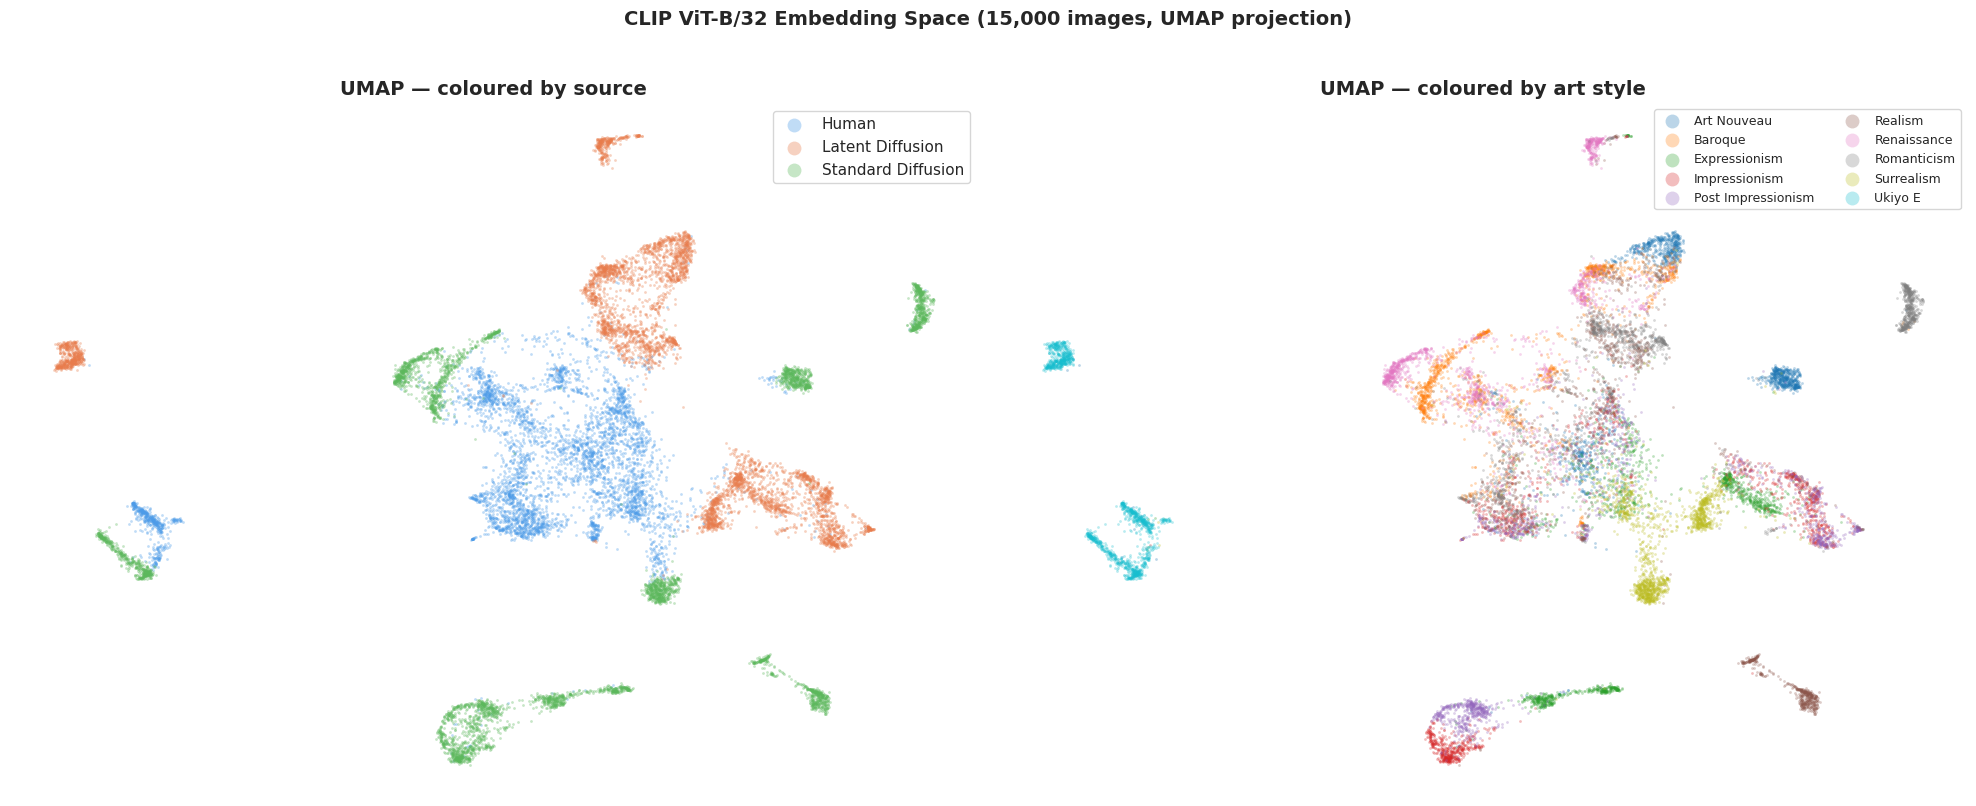

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

ax = axes[0]
for src, color in COLORS.items():
    mask = src_sample == src
    ax.scatter(E_2d[mask, 0], E_2d[mask, 1],
               c=color, label=src.replace('_', ' ').title(),
               alpha=0.35, s=4, linewidths=0)
ax.set_title('UMAP — coloured by source', fontweight='bold', fontsize=14)
ax.legend(markerscale=5, fontsize=11)
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
ax.axis('off')

ax2   = axes[1]
styles = sorted(np.unique(style_sample))
palette = sns.color_palette('tab10', n_colors=len(styles))
for style, color in zip(styles, palette):
    mask = style_sample == style
    ax2.scatter(E_2d[mask, 0], E_2d[mask, 1],
                c=[color], label=style.replace('_', ' ').title(),
                alpha=0.3, s=4, linewidths=0)
ax2.set_title('UMAP — coloured by art style', fontweight='bold', fontsize=14)
ax2.legend(markerscale=5, fontsize=9, ncol=2)
ax2.set_xlabel('UMAP-1'); ax2.set_ylabel('UMAP-2')
ax2.axis('off')

plt.suptitle('CLIP ViT-B/32 Embedding Space (15,000 images, UMAP projection)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/05_umap.png', dpi=150, bbox_inches='tight')
plt.show()

## Linear probe classifier

In [6]:
%%time
clf = LogisticRegression(
    C           = 1.0,
    max_iter    = 1000,
    solver      = 'lbfgs',
    random_state= 42,
    n_jobs      = -1
)
clf.fit(X_train, y_train)

y_pred  = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]  

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f'Binary classification (Human vs AI)')
print(f'  Accuracy : {acc*100:.2f}%')
print(f'  ROC-AUC  : {auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Human', 'AI']))

Binary classification (Human vs AI)
  Accuracy : 99.49%
  ROC-AUC  : 0.9998

              precision    recall  f1-score   support

       Human       0.99      0.99      0.99     10000
          AI       1.00      1.00      1.00     20000

    accuracy                           0.99     30000
   macro avg       0.99      0.99      0.99     30000
weighted avg       0.99      0.99      0.99     30000

CPU times: user 684 ms, sys: 864 ms, total: 1.55 s
Wall time: 7.16 s


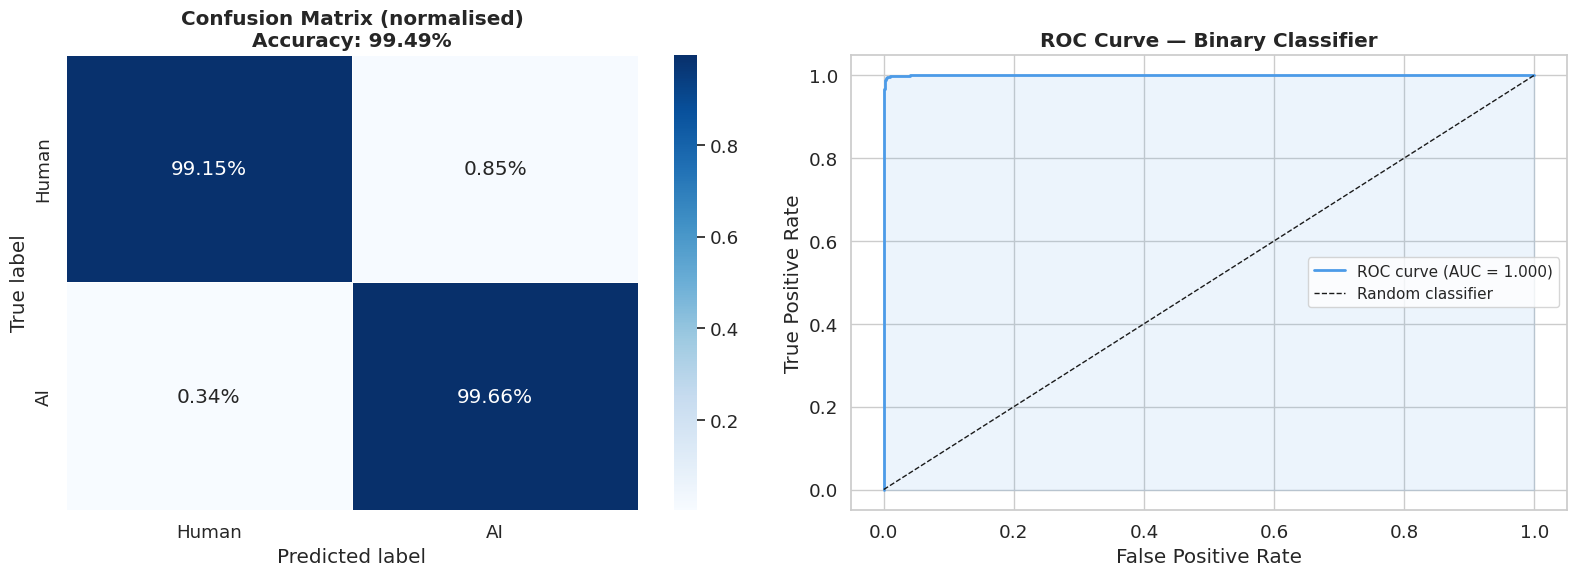

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, y_pred, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Human', 'AI'],
            yticklabels=['Human', 'AI'],
            ax=axes[0], linewidths=0.5)
axes[0].set_title(f'Confusion Matrix (normalised)\nAccuracy: {acc*100:.2f}%',
                  fontweight='bold')
axes[0].set_ylabel('True label')
axes[0].set_xlabel('Predicted label')


fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#4C9BE8', lw=2, label=f'ROC curve (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#4C9BE8')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Binary Classifier', fontweight='bold')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/06_confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## Per-style accuracy breakdown

In [8]:

style_results = []
for style in sorted(np.unique(sty_test)):
    mask       = sty_test == style
    y_true_s   = y_test[mask]
    y_pred_s   = y_pred[mask]
    y_proba_s  = y_proba[mask]
    n          = mask.sum()
    acc_s      = accuracy_score(y_true_s, y_pred_s)

    try:
        auc_s = roc_auc_score(y_true_s, y_proba_s)
    except Exception:
        auc_s = float('nan')
    style_results.append({'style': style, 'n': n, 'accuracy': acc_s, 'auc': auc_s})

style_df = pd.DataFrame(style_results).sort_values('accuracy')
print('Per-style accuracy (sorted worst → best):')
print(style_df.to_string(index=False))

Per-style accuracy (sorted worst → best):
             style    n  accuracy      auc
        surrealism 3000  0.989333 0.999367
           realism 3000  0.993333 0.999868
           ukiyo_e 3000  0.993333 0.999425
       romanticism 3000  0.994000 0.999727
       renaissance 3000  0.995000 0.999650
           baroque 3000  0.995667 0.999921
     expressionism 3000  0.996333 0.999888
       art_nouveau 3000  0.997000 0.999984
post_impressionism 3000  0.997333 0.999966
     impressionism 3000  0.997667 0.999950


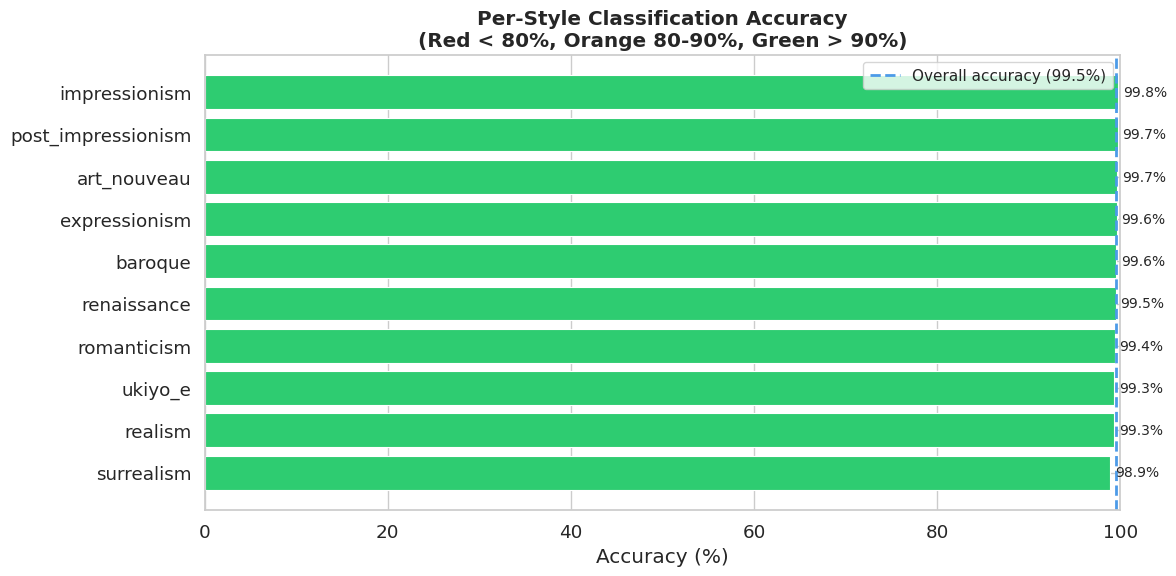

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
colors  = ['#E74C3C' if a < 0.80 else '#F39C12' if a < 0.90 else '#2ECC71'
           for a in style_df['accuracy']]
bars = ax.barh(style_df['style'], style_df['accuracy'] * 100,
               color=colors, edgecolor='white', linewidth=0.8)
ax.axvline(x=acc*100, color='#4C9BE8', linestyle='--', lw=2,
           label=f'Overall accuracy ({acc*100:.1f}%)')
ax.set_xlabel('Accuracy (%)')
ax.set_title('Per-Style Classification Accuracy\n(Red < 80%, Orange 80-90%, Green > 90%)',
             fontweight='bold')
ax.set_xlim(0, 100)
for bar, val in zip(bars, style_df['accuracy']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=10)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/07_per_style_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## Per-source accuracy breakdown

In [10]:
print('Per-source accuracy on test set:')
print()
for src in ['human', 'latent_diffusion', 'standard_diffusion']:
    mask    = src_test == src
    y_true_s = y_test[mask]
    y_pred_s = y_pred[mask]
    acc_s    = accuracy_score(y_true_s, y_pred_s)
    n        = mask.sum()
    print(f'  {src:25s}: {acc_s*100:.2f}%  (n={n:,})')


Per-source accuracy on test set:

  human                    : 99.15%  (n=10,000)
  latent_diffusion         : 99.58%  (n=10,000)
  standard_diffusion       : 99.74%  (n=10,000)


## Cross-generator generalization

In [11]:
%%time
ld_train_mask = (meta['split'] == 'train') & (meta['source'].isin(['human', 'latent_diffusion']))
X_ld_train    = E[ld_train_mask]
y_ld_train    = meta.loc[ld_train_mask, 'label'].values

clf_ld = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs',
                             random_state=42, n_jobs=-1)
clf_ld.fit(X_ld_train, y_ld_train)

ld_test_mask = (meta['split'] == 'test') & (meta['source'].isin(['human', 'latent_diffusion']))
X_ld_test    = E[ld_test_mask]
y_ld_test    = meta.loc[ld_test_mask, 'label'].values
acc_ld_in    = accuracy_score(y_ld_test, clf_ld.predict(X_ld_test))

sd_test_mask = (meta['split'] == 'test') & (meta['source'].isin(['human', 'standard_diffusion']))
X_sd_test    = E[sd_test_mask]
y_sd_test    = meta.loc[sd_test_mask, 'label'].values
acc_sd_ood   = accuracy_score(y_sd_test, clf_ld.predict(X_sd_test))

print('Cross-generator generalization:')
print(f'  Trained on         : Human vs Latent Diffusion')
print(f'  In-distribution    : {acc_ld_in*100:.2f}%  (LD test set)')
print(f'  Out-of-distribution: {acc_sd_ood*100:.2f}%  (SD test set — never seen)')
print()
drop = (acc_ld_in - acc_sd_ood) * 100
print(f'  Accuracy drop      : {drop:.2f} percentage points')
print()
if acc_sd_ood > 0.75:
    print('FINDING: Strong cross-generator generalization.')
    print('CLIP embeddings encode a general AI signature, not generator-specific artifacts.')
elif acc_sd_ood > 0.60:
    print('FINDING: Partial generalization.')
    print('Some features transfer across generators but there is a meaningful accuracy drop.')
else:
    print('FINDING: Poor cross-generator generalization.')
    print('The detector learned generator-specific features, not a general AI signature.')

Cross-generator generalization:
  Trained on         : Human vs Latent Diffusion
  In-distribution    : 99.74%  (LD test set)
  Out-of-distribution: 51.49%  (SD test set — never seen)

  Accuracy drop      : 48.25 percentage points

FINDING: Poor cross-generator generalization.
The detector learned generator-specific features, not a general AI signature.
CPU times: user 700 ms, sys: 441 ms, total: 1.14 s
Wall time: 3.59 s


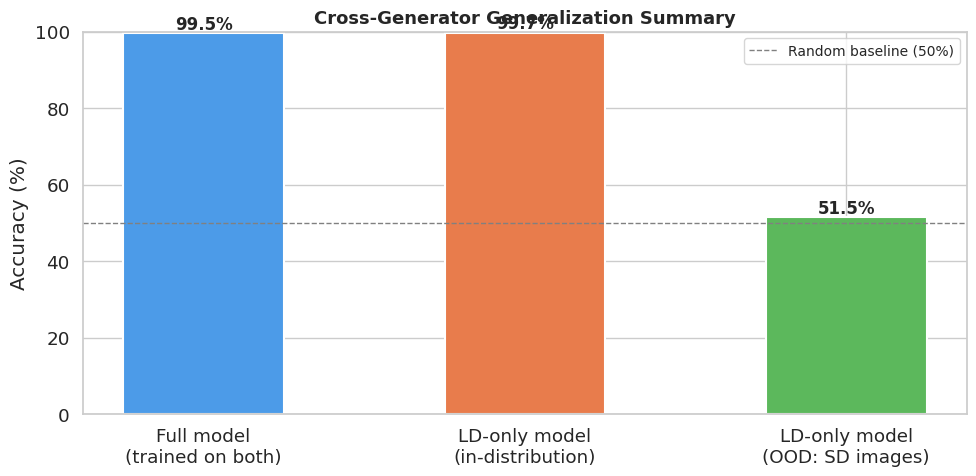

In [12]:

results = {
    'Full model\n(trained on both)': acc * 100,
    'LD-only model\n(in-distribution)': acc_ld_in * 100,
    'LD-only model\n(OOD: SD images)': acc_sd_ood * 100,
}
colors_bar = ['#4C9BE8', '#E87C4C', '#5CB85C']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(results.keys(), results.values(), color=colors_bar,
              edgecolor='white', linewidth=1.5, width=0.5)
ax.axhline(y=50, color='gray', linestyle='--', lw=1, label='Random baseline (50%)')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100)
ax.set_title('Cross-Generator Generalization Summary', fontweight='bold', fontsize=13)
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/08_generalization.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary of findings

In [13]:
best_style  = style_df.iloc[-1]
worst_style = style_df.iloc[0]

print(f'Model          : Logistic regression on frozen CLIP ViT-B/32')
print(f'Binary acc     : {acc*100:.2f}%')
print(f'ROC-AUC        : {auc:.4f}')
print(f'Best style     : {best_style.style} ({best_style.accuracy*100:.1f}%)')
print(f'Worst style    : {worst_style.style} ({worst_style.accuracy*100:.1f}%)')
print(f'OOD transfer   : {acc_sd_ood*100:.2f}%  (trained on LD, tested on SD)')
print()

print('1. CLIP embeddings linearly separate human vs AI art without task-specific training')
print('2. Style-controlled similarity shows AI images cluster together in embedding space')
print(f'3. Worst-performing style ({worst_style.style}) = most forensically ambiguous')
print('4. Cross-generator generalization measures whether signal is general or specific')
print()


Model          : Logistic regression on frozen CLIP ViT-B/32
Binary acc     : 99.49%
ROC-AUC        : 0.9998
Best style     : impressionism (99.8%)
Worst style    : surrealism (98.9%)
OOD transfer   : 51.49%  (trained on LD, tested on SD)

1. CLIP embeddings linearly separate human vs AI art without task-specific training
2. Style-controlled similarity shows AI images cluster together in embedding space
3. Worst-performing style (surrealism) = most forensically ambiguous
4. Cross-generator generalization measures whether signal is general or specific

